# Load the dataset

In [1]:
import pandas as pd
from scipy.io import arff

In [2]:
data, meta = arff.loadarff('Rice_Cammeo_Osmancik.arff')

In [3]:
df = pd.DataFrame(data)
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,b'Cammeo'
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,b'Cammeo'
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,b'Cammeo'
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,b'Cammeo'
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,b'Cammeo'


# Null values, duplicate values, error values and data type
According to the EDA, This dataset doesn't contain any null values, duplicate values, error values and data types are accurate

# Outliers

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

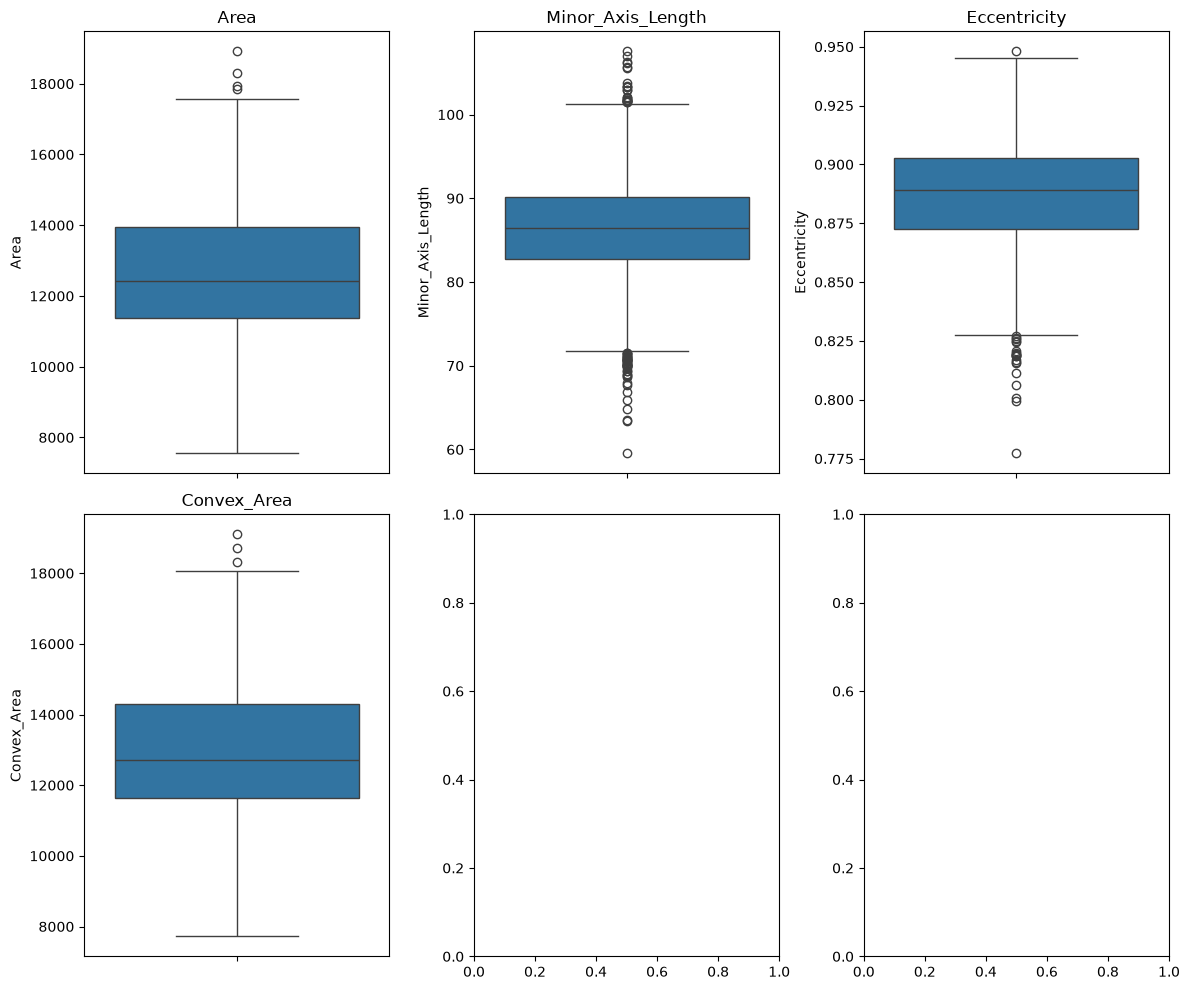

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns.drop(['Class','Perimeter','Major_Axis_Length','Extent'])):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

Some features contain IQR-identified outliers. After examining the observations, there is no evidence that these values are data-entry or measurement errors. Therefore, the observations are retained, and their potential influence on Logistic Regression is considered when selecting the scaling method.

# Skewness

The numerical features show only mild skewness. Since there is no strong evidence that transformation is required to improve the feature representation, no log or other skewness-reducing transformation is applied.

# Feature redundancy
Area and Convex_Area show very similar distributions, as observed from their boxplots and descriptive statistics. The scatter plot also shows an extremely strong linear relationship between the two features, which is supported by their correlation coefficient of approximately 1.00. Both features exhibit similar class patterns. Therefore, Area and Convex_Area contain highly similar information and may be redundant. To reduce potential redundancy in Logistic Regression, we will evaluate a reduced feature set by removing one of these features and compare its performance with the model using both features.

In [6]:
features_set1 = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent']
features_set2 = ['Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent']
features_set3 = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Extent']

# Train/test split

In [7]:
# Set 1
X_set1 = df[features_set1]
X_set2 = df[features_set2]
X_set3 = df[features_set3]
y = df["Class"]

## Convert bytes to strings

In [8]:
y = y.apply(
    lambda x: x.decode('utf-8') if isinstance(x, bytes) else x
)

In [9]:
print(y.unique())
print(type(y.iloc[0]))

<ArrowStringArray>
['Cammeo', 'Osmancik']
Length: 2, dtype: str
<class 'str'>


In [10]:
from sklearn.model_selection import train_test_split

X_train_set1, X_test_set1, y_train_set1, y_test_set1 = train_test_split(
    X_set1,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
X_train_set2, X_test_set2, y_train_set2, y_test_set2 = train_test_split(
    X_set2,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
X_train_set3, X_test_set3, y_train_set3, y_test_set3 = train_test_split(
    X_set3,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Feature scaling

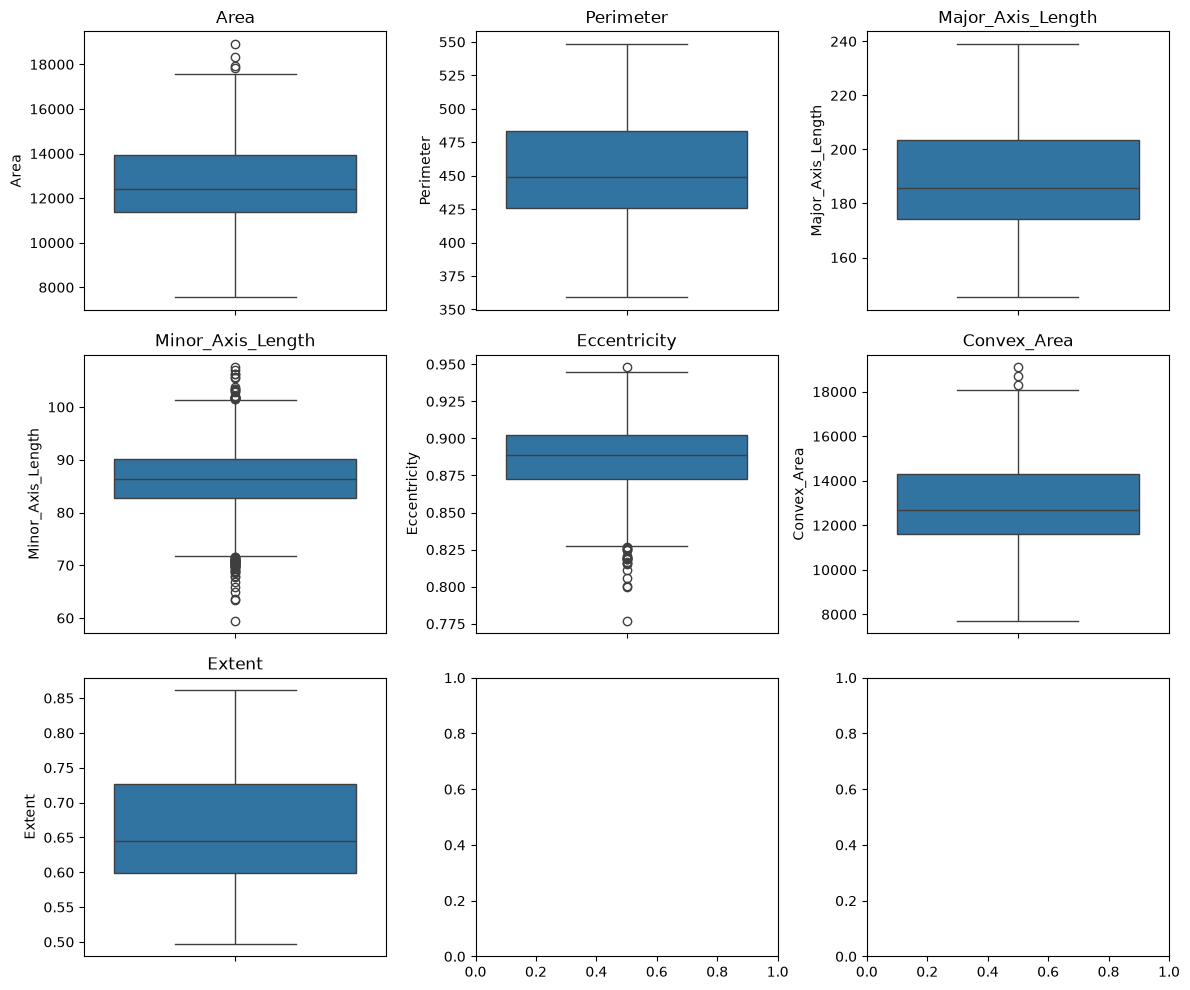

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns.drop('Class')):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

Features with outliers can scale using non-sensitive scaling method such as Robust scaling and others can scale using Standard Scaler

In [12]:
features_outliers = ['Eccentricity', 'Minor_Axis_Length', 'Area']
features_non_outliers  = ['Extent', 'Major_Axis_Length', 'Perimeter']

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled_non_outliers = scaler.fit_transform(X_train_set3[features_non_outliers])
X_test_scaled_non_outliers = scaler.transform(X_test_set3[features_non_outliers])

In [14]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled_outliers = scaler.fit_transform(X_train_set3[features_outliers])
X_test_scaled_outliers = scaler.transform(X_test_set3[features_outliers])

In [15]:
# Combine the scaled features

X_train_scaled = pd.concat([
    pd.DataFrame(
        X_train_scaled_non_outliers,
        columns=features_non_outliers,
        index=X_train_set3.index
    ),
    pd.DataFrame(
        X_train_scaled_outliers,
        columns=features_outliers,
        index=X_train_set3.index
    )
], axis=1)


X_test_scaled = pd.concat([
    pd.DataFrame(
        X_test_scaled_non_outliers,
        columns=features_non_outliers,
        index=X_test_set3.index
    ),
    pd.DataFrame(
        X_test_scaled_outliers,
        columns=features_outliers,
        index=X_test_set3.index
    )
], axis=1)

In [16]:
# Basic KNN implementation

from sklearn.neighbors import KNeighborsClassifier

# Create the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train_set3)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

print("Model trained successfully!")

Model trained successfully!


In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy_knn = accuracy_score(y_test_set3, y_pred_knn)

print("Accuracy:", accuracy_knn)

print("\nClassification Report:")
print(classification_report(y_test_set3, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_set3, y_pred_knn))

Accuracy: 0.9094488188976378

Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.91      0.88      0.89       326
    Osmancik       0.91      0.93      0.92       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762


Confusion Matrix:
[[286  40]
 [ 29 407]]


## Hyperparameter tuning

In [18]:
from sklearn.model_selection import GridSearchCV

knn_model = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21]
}

grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_knn.fit(X_train_scaled, y_train_set3)

print("Best Parameters:", grid_search_knn.best_params_)
print("Best CV Accuracy:", grid_search_knn.best_score_)

Best Parameters: {'n_neighbors': 15}
Best CV Accuracy: 0.9278214756790224


In [19]:
# Obtain best model

best_knn_model = grid_search_knn.best_estimator_

y_pred_knn = best_knn_model.predict(X_test_scaled)

## Evaluate best model

In [20]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy_knn = accuracy_score(y_test_set3, y_pred_knn)

print("Test Accuracy:", accuracy_knn)

print("\nClassification Report:")
print(classification_report(y_test_set3, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_set3, y_pred_knn))

Test Accuracy: 0.9146981627296588

Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.91      0.89      0.90       326
    Osmancik       0.92      0.94      0.93       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762


Confusion Matrix:
[[289  37]
 [ 28 408]]


### Extract the results

In [21]:
results_knn = grid_search_knn.cv_results_

for k, score in zip(
    results_knn['param_n_neighbors'],
    results_knn['mean_test_score']
):
    print(f"K = {k}, CV Accuracy = {score:.4f}")

K = 3, CV Accuracy = 0.9176
K = 5, CV Accuracy = 0.9226
K = 7, CV Accuracy = 0.9249
K = 9, CV Accuracy = 0.9272
K = 11, CV Accuracy = 0.9268
K = 15, CV Accuracy = 0.9278
K = 21, CV Accuracy = 0.9265


### Plot the chart

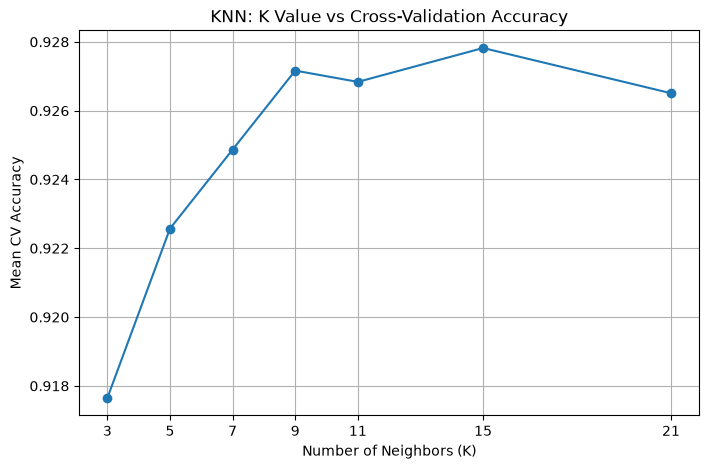

In [22]:
import matplotlib.pyplot as plt

k_values = results_knn['param_n_neighbors'].data
cv_scores = results_knn['mean_test_score']

plt.figure(figsize=(8, 5))

plt.plot(k_values, cv_scores, marker='o')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN: K Value vs Cross-Validation Accuracy")

plt.xticks(k_values)
plt.grid(True)

plt.show()